# Hyperparameter search with Katib

Goal:

- Search YOLO training hyperparameters with Katib instead of guessing them.
- Each trial is a **pod** running the training image, not a notebook cell.
- Compare trials by validation mAP and keep the winning configuration.


## Environment

Install dependencies.


In [1]:
# pip install
%pip install -q -U kubeflow-katib kubernetes

Note: you may need to restart the kernel to use updated packages.


Inspect environment.

- Train image: 099139718958.dkr.ecr.ca-central-1.amazonaws.com/kubeflow-yolo-train:v0.1.0


In [2]:
# inspect env
import os
from pathlib import Path

from kubeflow.katib import KatibClient
from kubernetes.client import V1ObjectMeta
from kubeflow.katib import V1beta1AlgorithmSpec
from kubeflow.katib import V1beta1Experiment
from kubeflow.katib import V1beta1ExperimentSpec
from kubeflow.katib import V1beta1FeasibleSpace
from kubeflow.katib import V1beta1ObjectiveSpec
from kubeflow.katib import V1beta1ParameterSpec
from kubeflow.katib import V1beta1TrialTemplate

# the profile namespace this notebook runs in; trials land here too
NAMESPACE = os.environ.get("NAMESPACE", "kubeflow-yolo")

ACCOUNT = "099139718958"
REGION = "ca-central-1"
# gpu image
IMAGE = f"{ACCOUNT}.dkr.ecr.{REGION}.amazonaws.com/kubeflow-yolo-train:v0.1.0"

EXPERIMENT_NAME = "kubeflow-yolo-plate"

print("namespace  ", NAMESPACE)
print("image      ", IMAGE)

namespace   kubeflow-yolo
image       099139718958.dkr.ecr.ca-central-1.amazonaws.com/kubeflow-yolo-train:v0.1.0


---

## Hyperparameters

Four parameters, chosen for a single-class small-object detector:

| Parameter | Range       | Why                                                          |
| --------- | ----------- | ------------------------------------------------------------ |
| `lr0`     | 1e-4 – 2e-2 | the highest-impact single knob                               |
| `batch`   | 4 – 24      | gradient noise; interacts with `lr0`                         |
| `box`     | 5 – 12      | box loss gain — with one class, localization is what matters |
| `scale`   | 0.3 – 0.9   | plate size varies with camera distance                       |


In [3]:
# define parameters
parameters = [
    V1beta1ParameterSpec(
        name="lr0",
        parameter_type="double",
        feasible_space=V1beta1FeasibleSpace(min="0.0001", max="0.02"),
    ),
    V1beta1ParameterSpec(
        name="batch",
        parameter_type="int",
        feasible_space=V1beta1FeasibleSpace(min="4", max="24", step="4"),
    ),
    V1beta1ParameterSpec(
        name="box",
        parameter_type="double",
        feasible_space=V1beta1FeasibleSpace(min="5.0", max="12.0"),
    ),
    V1beta1ParameterSpec(
        name="scale",
        parameter_type="double",
        feasible_space=V1beta1FeasibleSpace(min="0.3", max="0.9"),
    ),
]

for p in parameters:
    fs = p.feasible_space
    print(f"{p.name:8} {p.parameter_type:7} {fs.min} .. {fs.max}")

lr0      double  0.0001 .. 0.02
batch    int     4 .. 24
box      double  5.0 .. 12.0
scale    double  0.3 .. 0.9


### Objective

- `train.py` returns `name=value` lines at the end of a run;
- Katib's default collector scrapes stdout for them.

```
mAP50=0.812345
mAP50-95=0.643210
precision=0.887654
recall=0.791234
```

- `mAP50-95`: the stricter metric


In [4]:
objective = V1beta1ObjectiveSpec(
    type="maximize",
    goal=0.85,  # stop early if a trial reaches this
    objective_metric_name="mAP50-95",
    additional_metric_names=["mAP50", "precision", "recall"],
)

# bayesian optimization: strategy used to find the best input values
algorithm = V1beta1AlgorithmSpec(algorithm_name="bayesianoptimization")

print("objective   maximize", objective.objective_metric_name, "goal", objective.goal)
print("algorithm  ", algorithm.algorithm_name)

objective   maximize mAP50-95 goal 0.85
algorithm   bayesianoptimization


---

## Trial

Each trial is a `batch/v1` Job.

Notes on the pod spec:

- `restartPolicy: Never` -- a failed trial should be reported, not retried.
- `sidecar.istio.io/inject: "false"` -- the mesh sidecar never exits, so the Job
  would hang forever waiting for it.
- The gpu nodepool is tainted `workload-class=gpu:NoSchedule` and the nvidia
  device plugin adds `nvidia.com/gpu:NoSchedule`, so a trial needs both
  tolerations plus the `workload-class: gpu` selector.
- One GPU per trial on `g5.xlarge` (1x A10G). `parallelTrialCount` below is
  therefore also the number of GPU nodes Karpenter will provision.

**Dataset.** The training image ships no data (`data/` is in `.dockerignore`),
so the dataset comes from the shared `dataset-raw` PVC, mounted read-only at
`/data`. It is `ReadWriteMany` on EFS because a `ReadWriteOnce` EBS volume
binds to one node and parallel trials land on different nodes.

Because that mount is read-only, the split, the generated `data.yaml` and the
run outputs are redirected to an `emptyDir` at `/scratch`.

Populate the volume once before submitting:

```bash
kubectl apply -f kubeflow/katib/pvc.yaml
kubectl apply -f kubeflow/katib/populate-job.yaml
kubectl -n kubeflow-yolo wait --for=condition=complete job/dataset-populate --timeout=15m
```


In [5]:
trial_parameters = [
    {"name": "lr0", "description": "initial learning rate", "reference": "lr0"},
    {"name": "batch", "description": "batch size", "reference": "batch"},
    {"name": "box", "description": "box loss gain", "reference": "box"},
    {"name": "scale", "description": "augmentation scale gain", "reference": "scale"},
]

trial_spec = {
    "apiVersion": "batch/v1",
    "kind": "Job",
    "spec": {
        "template": {
            "metadata": {
                "annotations": {
                    # the sidecar never exits, so an injected trial Job hangs
                    "sidecar.istio.io/inject": "false"
                }
            },
            "spec": {
                "restartPolicy": "Never",
                # carries the S3 pod identity association
                "serviceAccountName": "default-editor",
                # the gpu nodepool is tainted workload-class=gpu:NoSchedule, and
                # the nvidia device plugin adds its own taint on top
                "nodeSelector": {"workload-class": "gpu"},
                "tolerations": [
                    {
                        "key": "workload-class",
                        "operator": "Equal",
                        "value": "gpu",
                        "effect": "NoSchedule",
                    },
                    {"key": "nvidia.com/gpu", "operator": "Exists", "effect": "NoSchedule"},
                ],
                "containers": [
                    {
                        "name": "training-container",
                        "image": IMAGE,
                        "command": [
                            "python", "-m", "src.train",
                            # dataset is read-only on the shared volume; the split,
                            # descriptor and outputs must go somewhere writable
                            "--raw=/data/raw",
                            "--processed=/scratch/processed",
                            "--data-yaml=/scratch/data.yaml",
                            "--artifacts=/scratch/artifacts",
                            "--epochs=20",
                            "--imgsz=640",
                            "--device=0",
                            "--project=/scratch/runs",
                            "--lr0=${trialParameters.lr0}",
                            "--batch=${trialParameters.batch}",
                            "--box=${trialParameters.box}",
                            "--scale=${trialParameters.scale}",
                        ],
                        "volumeMounts": [
                            # every parallel trial mounts the same dataset
                            {"name": "dataset", "mountPath": "/data", "readOnly": True},
                            {"name": "scratch", "mountPath": "/scratch"},
                            # Dataloader workers share memory through /dev/shm.
                            {"name": "dshm", "mountPath": "/dev/shm"},
                        ],
                        # g5.xlarge is 4 vCPU / 16Gi / 1 A10G; leave headroom for
                        # the kubelet or the pod will not fit
                        "resources": {
                            "requests": {"cpu": "3", "memory": "12Gi", "nvidia.com/gpu": "1"},
                            "limits": {"cpu": "3", "memory": "12Gi", "nvidia.com/gpu": "1"},
                        },
                    }
                ],
                "volumes": [
                    {
                        "name": "dataset",
                        "persistentVolumeClaim": {
                            "claimName": "dataset-raw",
                            "readOnly": True,
                        },
                    },
                    {"name": "scratch", "emptyDir": {}},
                    # medium=Memory counts against the container memory limit,
                    # so this is carved out of the 12Gi, not added to it
                    {"name": "dshm", "emptyDir": {"medium": "Memory", "sizeLimit": "8Gi"}},
                ],
            },
        }
    },
}

trial_template = V1beta1TrialTemplate(
    primary_container_name="training-container",
    trial_parameters=trial_parameters,
    trial_spec=trial_spec,
    retain=True,  # keep finished trial pods so their logs stay readable
)

print("image      ", IMAGE)
print("parameters ", [p["name"] for p in trial_parameters])
print("dataset     pvc/dataset-raw -> /data (read-only)")
print("scheduling  workload-class=gpu, 1x nvidia.com/gpu per trial")

image       099139718958.dkr.ecr.ca-central-1.amazonaws.com/kubeflow-yolo-train:v0.1.0
parameters  ['lr0', 'batch', 'box', 'scale']
dataset     pvc/dataset-raw -> /data (read-only)
scheduling  workload-class=gpu, 1x nvidia.com/gpu per trial


---

## Submit

- `maxTrialCount`: the budget.
- `parallelTrialCount`: how many GPU nodes Karpenter runs at once.


In [6]:
metadata = V1ObjectMeta(
    name=EXPERIMENT_NAME,
    namespace=NAMESPACE,
)

experiment = V1beta1Experiment(
    api_version="kubeflow.org/v1beta1",
    kind="Experiment",
    metadata=metadata,
    spec=V1beta1ExperimentSpec(
        objective=objective,
        algorithm=algorithm,
        parameters=parameters,
        trial_template=trial_template,
        max_trial_count=12,
        parallel_trial_count=2,  # = concurrent g5.xlarge nodes
        max_failed_trial_count=3,
    ),
)

client = KatibClient(namespace=NAMESPACE)

client.create_experiment(experiment, namespace=NAMESPACE)

print("submitted  ", EXPERIMENT_NAME)

submitted   kubeflow-yolo-plate


### Monitor progress

Log progress in noetbook.


In [7]:
import time


def experiment_condition(exp):
    """Latest condition type on the experiment, or '' before the controller acts."""
    conditions = (exp.status.conditions if exp.status else None) or []
    return conditions[-1].type if conditions else ""


def count(status, field):
    """status is absent until the controller first reconciles the experiment."""
    return getattr(status, field, None) or 0 if status else 0


while True:
    exp = client.get_experiment(name=EXPERIMENT_NAME, namespace=NAMESPACE)
    status = experiment_condition(exp)
    st = exp.status

    print(
        f"{status or 'Pending':12} "
        f"trials: {count(st, 'trials')} "
        f"succeeded {count(st, 'trials_succeeded')} "
        f"running {count(st, 'trials_running')} "
        f"failed {count(st, 'trials_failed')}"
    )

    if status in ("Succeeded", "Failed"):
        break
    time.sleep(60)

Created      trials: 0 succeeded 0 running 0 failed 0
Running      trials: 2 succeeded 0 running 2 failed 0
Running      trials: 2 succeeded 0 running 2 failed 0
Running      trials: 2 succeeded 0 running 2 failed 0
Running      trials: 3 succeeded 1 running 2 failed 0
Running      trials: 4 succeeded 2 running 2 failed 0
Running      trials: 4 succeeded 2 running 2 failed 0
Running      trials: 4 succeeded 2 running 2 failed 0
Running      trials: 6 succeeded 4 running 2 failed 0
Running      trials: 6 succeeded 4 running 2 failed 0
Running      trials: 7 succeeded 5 running 2 failed 0
Running      trials: 8 succeeded 6 running 2 failed 0
Running      trials: 8 succeeded 6 running 2 failed 0
Running      trials: 9 succeeded 7 running 2 failed 0
Running      trials: 10 succeeded 8 running 2 failed 0
Running      trials: 10 succeeded 8 running 2 failed 0
Running      trials: 10 succeeded 8 running 2 failed 0
Running      trials: 11 succeeded 9 running 2 failed 0
Running      trials: 12 

---

## Results

Get the optimal assignment Katib converged on.


In [8]:
best = client.get_optimal_hyperparameters(
    name=EXPERIMENT_NAME, namespace=NAMESPACE
)

print("best objective")
for m in best.observation.metrics:
    print(f"  {m.name:12} {m.latest}")

print("\nbest parameters")
for a in best.parameter_assignments:
    print(f"  {a.name:8} {a.value}")

best objective
  mAP50-95     0.823961
  mAP50        0.965089
  precision    0.919864
  recall       0.890607

best parameters
  lr0      0.01754714912637942
  batch    5
  box      5.631316900416694
  scale    0.3678926922779834


In [10]:
import pandas as pd

from kubeflow.katib.constants import constants

response = client.custom_api.list_namespaced_custom_object(
    constants.KUBEFLOW_GROUP,
    constants.KATIB_VERSION,
    namespace=NAMESPACE,
    plural=constants.TRIAL_PLURAL,
    label_selector=f"{constants.EXPERIMENT_LABEL}={EXPERIMENT_NAME}",
)

rows = []
for t in response["items"]:
    status = t.get("status", {})
    conditions = status.get("conditions") or []

    row = {
        "trial": t["metadata"]["name"],
        "status": conditions[-1]["type"] if conditions else "Pending",
    }
    for a in t["spec"].get("parameterAssignments") or []:
        row[a["name"]] = float(a["value"])
    for m in (status.get("observation") or {}).get("metrics") or []:
        row[m["name"]] = float(m["latest"])
    rows.append(row)

df = pd.DataFrame(rows).sort_values("mAP50-95", ascending=False, na_position="last")
df

,trial,status,lr0,batch,box,scale,mAP50-95,mAP50,precision,recall
11,kubeflow-yolo-plate-znhdslzz,Succeeded,0.017547,5.0,5.631317,0.367893,0.823961,0.965089,0.919864,0.890607
2,kubeflow-yolo-plate-7mbm85dt,Succeeded,0.000201,9.0,5.134534,0.527177,0.810153,0.964555,0.944409,0.922414
1,kubeflow-yolo-plate-7bv9bdxd,Succeeded,0.001067,22.0,5.059588,0.337439,0.809194,0.989095,0.949663,0.975838
9,kubeflow-yolo-plate-pltf9tf6,Succeeded,0.000496,4.0,5.000000,0.300000,0.809168,0.962426,0.975957,0.887931
5,kubeflow-yolo-plate-hpmm6wzb,Succeeded,0.010650,14.0,8.690669,0.320229,0.809144,0.966469,0.921692,0.905172
6,kubeflow-yolo-plate-k22mvv22,Succeeded,0.000303,21.0,6.248025,0.382352,0.806199,0.966309,0.971668,0.879310
3,kubeflow-yolo-plate-dnsh8ml8,Succeeded,0.000678,5.0,7.794010,0.571241,0.805604,0.967219,0.929860,0.914294
4,kubeflow-yolo-plate-h52ddpzp,Succeeded,0.012108,5.0,5.884242,0.764854,0.803543,0.956708,0.943597,0.865345
8,kubeflow-yolo-plate-mp9dnbxc,Succeeded,0.001766,20.0,6.019940,0.869066,0.799785,0.941627,0.932628,0.836207
7,kubeflow-yolo-plate-kmw7lszz,Succeeded,0.001606,8.0,8.600905,0.866740,0.792893,0.956210,0.919167,0.882264


### Which parameters mattered

A flat cloud means the parameter had little effect over this range; a trend
means it is worth searching more finely.


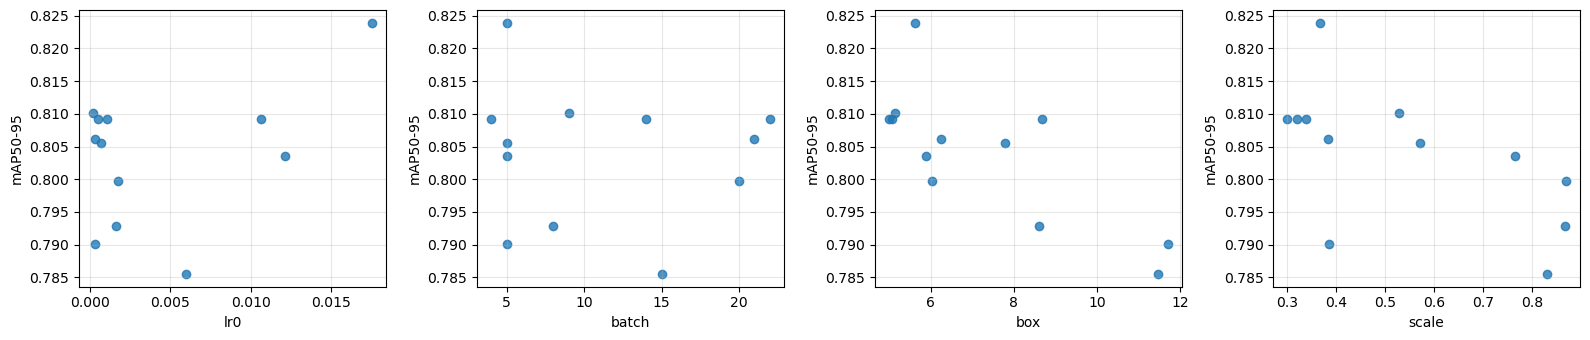

In [11]:
import matplotlib.pyplot as plt

searched = [p.name for p in parameters]
done = df[df["mAP50-95"].notna()]

fig, axes = plt.subplots(1, len(searched), figsize=(4 * len(searched), 3.5))
for ax, name in zip(axes, searched):
    ax.scatter(done[name], done["mAP50-95"], alpha=0.8)
    ax.set_xlabel(name)
    ax.set_ylabel("mAP50-95")
    ax.grid(alpha=0.3)
fig.tight_layout()

---

## Apply the result

Fold the winning assignment back into `train-job/configs/train.yaml`, then
retrain at full epochs with those values.

The experiment and its trial pods stay in the namespace until removed:

```python
client.delete_experiment(name=EXPERIMENT_NAME, namespace=NAMESPACE)
```


In [12]:
winning = {a.name: float(a.value) for a in best.parameter_assignments}
print("add to train-job/configs/train.yaml:\n")
for key, value in winning.items():
    print(f"{key}: {value:g}")

add to train-job/configs/train.yaml:

lr0: 0.0175471
batch: 5
box: 5.63132
scale: 0.367893
